# Chargement des images - MVTec Bottle

## 1. Imports et configuration

Chargement des bibliothèques nécessaires et définition des paramètres globaux (`IMG_SIZE`, `DATA_DIR`).

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)
DATA_DIR = r"C:\Formation\images\bottle"

## 2. Fonction de chargement

Parcourt récursivement les sous-dossiers (un label par dossier), redimensionne chaque image à `IMG_SIZE` et normalise les pixels dans `[0, 1]`.

In [2]:
def load_images(folder: str) -> tuple[np.ndarray, list[str]]:
    images, labels = [], []
    for label in sorted(os.listdir(folder)):
        label_dir = os.path.join(folder, label)
        if not os.path.isdir(label_dir):
            continue
        for fname in sorted(os.listdir(label_dir)):
            if not fname.lower().endswith((".png", ".jpg", ".bmp")):
                continue
            img = Image.open(os.path.join(label_dir, fname)).convert("RGB")
            img = img.resize(IMG_SIZE)
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(label)
    return np.stack(images), labels

## 3. Chargement du dataset

Chargement du dataset MVTec Bottle. Le dossier `train` ne contient que des images **saines** (`good`), tandis que `test` regroupe les défauts (`broken_large`, `broken_small`, `contamination`) et quelques saines.

In [3]:
X_train, y_train = load_images(os.path.join(DATA_DIR, "train"))
X_test,  y_test  = load_images(os.path.join(DATA_DIR, "test"))

print(f"Train : {X_train.shape}  min={X_train.min():.2f}  max={X_train.max():.2f}")
print(f"Test  : {X_test.shape}   min={X_test.min():.2f}  max={X_test.max():.2f}")
print(f"Labels train : {sorted(set(y_train))}")
print(f"Labels test  : {sorted(set(y_test))}")

Train : (209, 128, 128, 3)  min=0.11  max=1.00
Test  : (83, 128, 128, 3)   min=0.09  max=1.00
Labels train : ['good']
Labels test  : ['broken_large', 'broken_small', 'contamination', 'good']


## 4. Exploration visuelle

Aperçu des données : 5 images aléatoires du jeu de test, puis comparaison côte à côte d'images saines et d'images avec défauts.

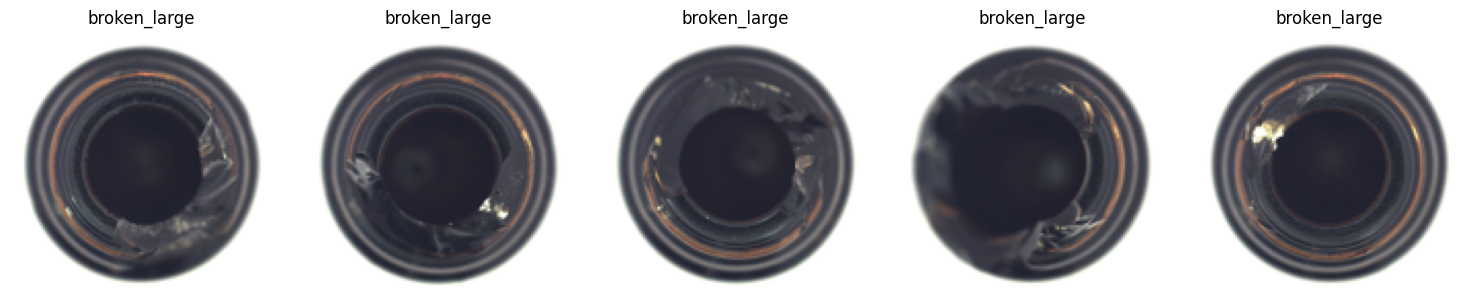

In [4]:
# Aperçu : 5 premières images du jeu de test
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, img, label in zip(axes, X_test[:5], y_test[:5]):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

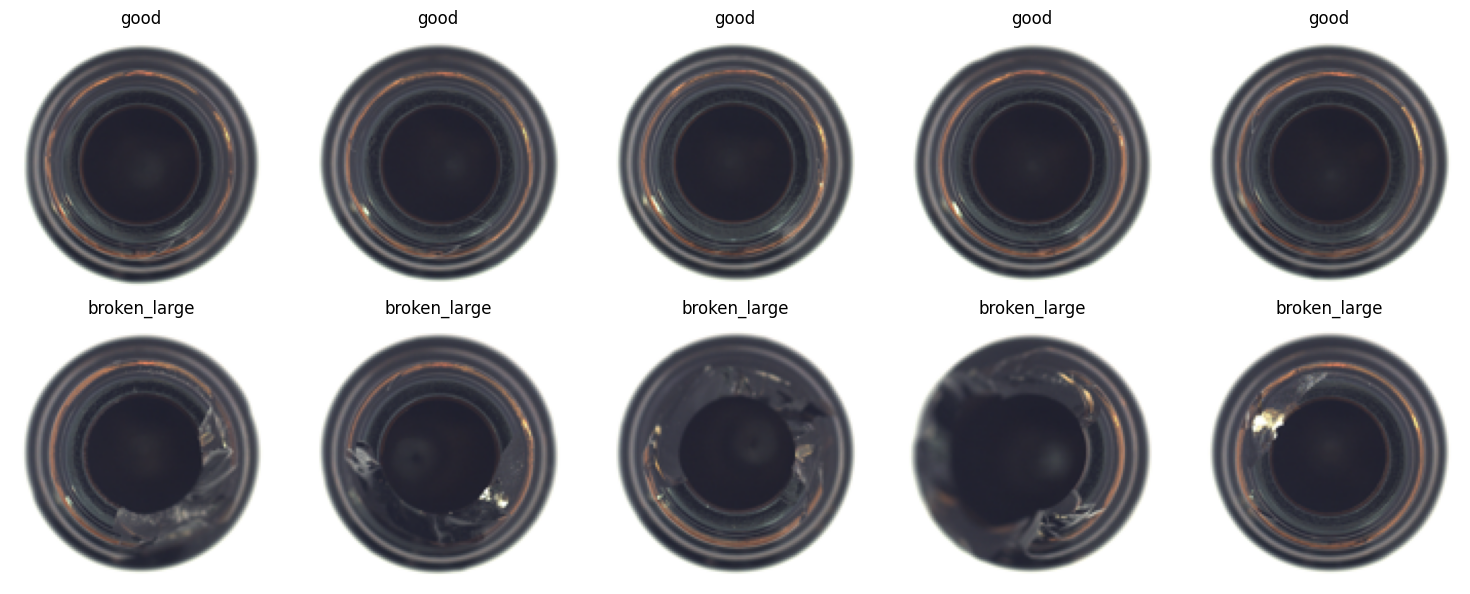

In [5]:
y_test_arr = np.array(y_test)

good_imgs     = X_test[y_test_arr == "good"][:5]
defect_imgs   = X_test[y_test_arr != "good"][:5]
defect_labels = y_test_arr[y_test_arr != "good"][:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img in zip(axes[0], good_imgs):
    ax.imshow(img); ax.set_title("good"); ax.axis("off")
for ax, img, lbl in zip(axes[1], defect_imgs, defect_labels):
    ax.imshow(img); ax.set_title(lbl); ax.axis("off")

axes[0, 0].set_ylabel("Saines", fontsize=12)
axes[1, 0].set_ylabel("Défauts", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Split entraînement / validation

Réservation de **20 %** des images saines pour surveiller la loss de reconstruction et calibrer le seuil d'anomalie, sans toucher au jeu de test.

In [6]:
from sklearn.model_selection import train_test_split

# Réservation de 20 % des images saines pour la validation
X_train_fit, X_val = train_test_split(X_train, test_size=0.2, random_state=42)

print(f"Entraînement : {X_train_fit.shape}")
print(f"Validation   : {X_val.shape}")

Entraînement : (167, 128, 128, 3)
Validation   : (42, 128, 128, 3)


## 6. Pipeline d'augmentation

Augmentation appliquée **uniquement aux images saines d'entraînement** (`X_train_fit`) pour enrichir le jeu de données sans introduire de biais. Chaque image génère 3 variantes, ce qui multiplie par ~4 le volume d'entraînement.

| Transformation | Paramètres |
|---|---|
| Flip horizontal / vertical | p = 0.5 / 0.3 |
| Rotation | ± 15° |
| Translation + échelle | ± 10 % |
| Luminosité + contraste | ± 20 % |
| Teinte / saturation | léger décalage |

Le résultat final est stocké dans `X_train_final`.

In [7]:
import albumentations as A

# Pipeline d'augmentation — appliqué uniquement aux images saines d'entraînement
augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=15, border_mode=0, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
])

def apply_augmentation(images: np.ndarray, n_aug: int = 3) -> np.ndarray:
    result = []
    for img in images:
        img_u8 = (img * 255).astype(np.uint8)
        for _ in range(n_aug):
            aug = augment_pipeline(image=img_u8)["image"]
            result.append(aug.astype(np.float32) / 255.0)
    return np.stack(result)

X_aug = apply_augmentation(X_train_fit, n_aug=3)
X_train_final = np.concatenate([X_train_fit, X_aug])
np.random.default_rng(42).shuffle(X_train_final)

print(f"Original  : {X_train_fit.shape}")
print(f"Augmenté  : {X_aug.shape}")
print(f"Total     : {X_train_final.shape}")

c:\indusense\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Original  : (167, 128, 128, 3)
Augmenté  : (501, 128, 128, 3)
Total     : (668, 128, 128, 3)


## 7. Visualisation de l'augmentation

Comparaison entre une image originale et 4 versions augmentées pour vérifier visuellement que les transformations restent réalistes.

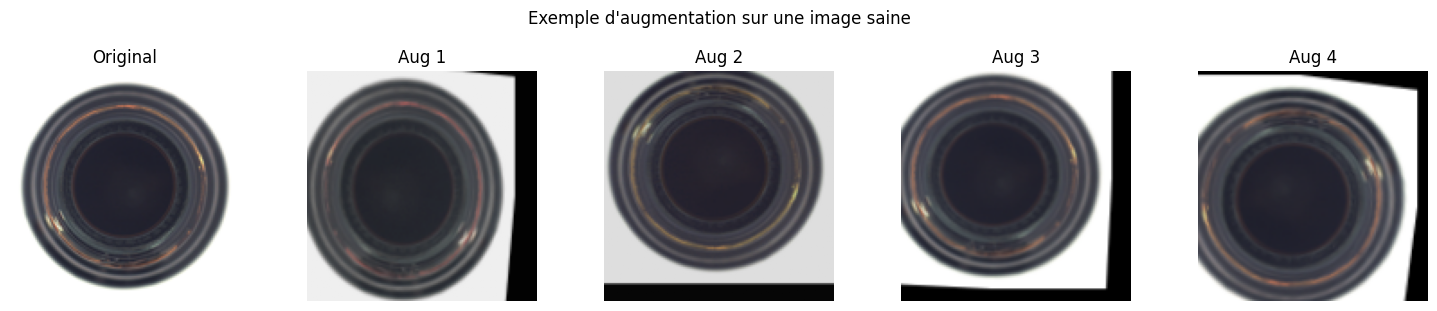

In [8]:
# Visualisation : 1 image originale + 4 versions augmentées
sample_u8 = (X_train_fit[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(X_train_fit[0]); axes[0].set_title("Original"); axes[0].axis("off")
for i, ax in enumerate(axes[1:], 1):
    aug = augment_pipeline(image=sample_u8)["image"].astype(np.float32) / 255.0
    ax.imshow(aug); ax.set_title(f"Aug {i}"); ax.axis("off")

plt.suptitle("Exemple d'augmentation sur une image saine", y=1.02)
plt.tight_layout()
plt.show()

## 8. Auto-encodeur convolutif

Architecture symétrique encodeur / décodeur :
- **Encodeur** : 3 × `Conv2D` avec `strides=2` — réduit la résolution spatiale par 2 à chaque étape.
- **Goulot d'étranglement** : représentation compressée à `16 × 16 × 128`.
- **Décodeur** : 3 × `Conv2DTranspose` avec `strides=2` — reconstruit progressivement jusqu'à `128 × 128 × 3`.
- **Sortie `sigmoid`** : garantit des pixels dans `[0, 1]`, cohérent avec la normalisation des images.

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_autoencoder(input_shape=(128, 128, 3)):
    inputs = keras.Input(shape=input_shape)

    # ── Encodeur ──────────────────────────────────────────
    x = layers.Conv2D(32,  3, strides=2, padding="same", activation="relu")(inputs)  # → 64×64×32
    x = layers.Conv2D(64,  3, strides=2, padding="same", activation="relu")(x)       # → 32×32×64
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)       # → 16×16×128  ← goulot

    # ── Décodeur ──────────────────────────────────────────
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)      # → 32×32×64
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)      # → 64×64×32
    x = layers.Conv2DTranspose(3,  3, strides=2, padding="same", activation="sigmoid")(x)   # → 128×128×3

    return keras.Model(inputs, x, name="autoencoder")

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)

### Analyse du modèle

**Nombre de paramètres**

| Couche | Calcul | Paramètres |
|---|---|---|
| Conv2D 32 | (3×3×3 + 1) × 32 | 896 |
| Conv2D 64 | (3×3×32 + 1) × 64 | 18 496 |
| Conv2D 128 | (3×3×64 + 1) × 128 | 73 856 |
| Conv2DTranspose 64 | (3×3×128 + 1) × 64 | 73 792 |
| Conv2DTranspose 32 | (3×3×64 + 1) × 32 | 18 464 |
| Conv2DTranspose 3 | (3×3×32 + 1) × 3 | 867 |
| **Total** | | **≈ 186 000** |

Le modèle est **très léger** (~186 K paramètres), ce qui limite le risque de sur-apprentissage sur un dataset de ~670 images saines.

**Goulot d'étranglement**

$$16 \times 16 \times 128 = 32\,768 \text{ valeurs}$$

Face à une entrée de $128 \times 128 \times 3 = 49\,152$ valeurs, le taux de compression est **~1,5×**. Ce goulot est volontairement modéré : trop serré, le modèle ne peut pas reconstruire fidèlement les images saines ; trop large, il reconstruit aussi bien les anomalies et perd sa capacité de détection.

## 9. Entraînement — Reconstruction (cible = entrée)

Deux variantes sont entraînées en parallèle pour comparer les pertes :

| Perte | Principe | Avantage |
|---|---|---|
| **MSE** | Erreur quadratique pixel à pixel | Simple, rapide à converger |
| **SSIM** | Compare luminance, contraste et structure locale | Plus sensible aux altérations de texture (défauts industriels) |

Les deux utilisent l'optimiseur **Adam** et un `EarlyStopping` sur la val_loss (patience = 10).

In [10]:
EPOCHS     = 100
BATCH_SIZE = 32
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

# ── Entraînement MSE ──────────────────────────────────────
autoencoder_mse = build_autoencoder()
autoencoder_mse.compile(optimizer="adam", loss="mse")

history_mse = autoencoder_mse.fit(
    X_train_final, X_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.1145 - val_loss: 0.0903
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0704 - val_loss: 0.0339
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0335 - val_loss: 0.0116
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0142 - val_loss: 0.0051
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0089 - val_loss: 0.0039
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0070 - val_loss: 0.0034
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0056 - val_loss: 0.0032
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0047 - val_loss: 0.0029
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0041 - val_loss: 0.0025
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0038 - val_loss: 0.0024
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/st

In [11]:
# ── Perte SSIM (1 − SSIM moyen, à minimiser) ─────────────
def ssim_loss(y_true, y_pred):
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# ── Entraînement SSIM ─────────────────────────────────────
autoencoder_ssim = build_autoencoder()
autoencoder_ssim.compile(optimizer="adam", loss=ssim_loss)

history_ssim = autoencoder_ssim.fit(
    X_train_final, X_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - loss: 0.6537 - val_loss: 0.6174
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - loss: 0.5706 - val_loss: 0.4888
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - loss: 0.4217 - val_loss: 0.3271
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - loss: 0.3017 - val_loss: 0.2074
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.1815 - val_loss: 0.1226
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.1410 - val_loss: 0.1145
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - loss: 0.1293 - val_loss: 0.1087
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.1242 - val_loss: 0.1086
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - loss: 0.1159 - val_loss: 0.0983
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 0.1058 - val_loss: 0.1109
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - loss: 0.1016 - val_loss: 0.0921
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3

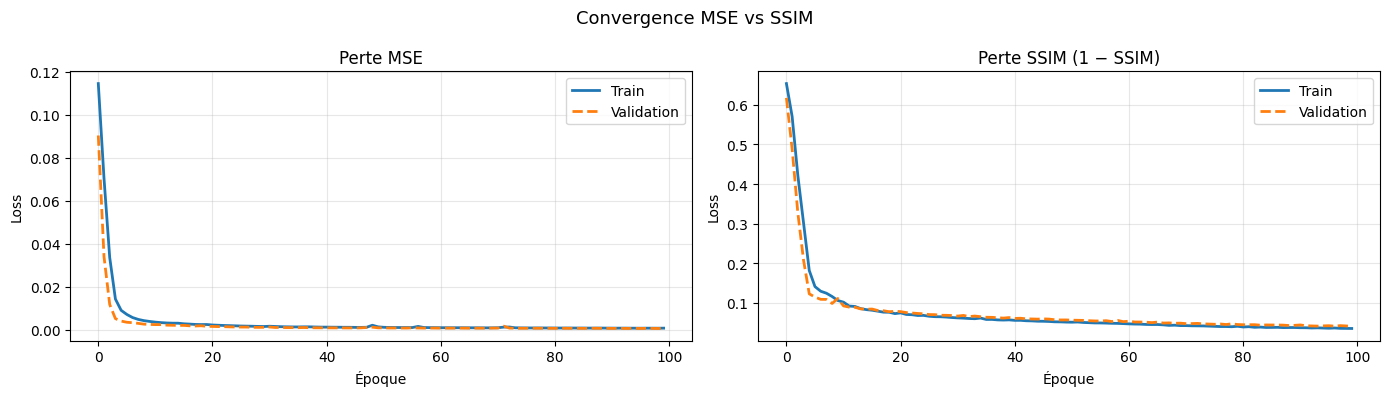

MSE  — val_loss finale : 0.000484
SSIM — val_loss finale : 0.040624  (SSIM moyen = 0.9594)


In [12]:
# ── Courbes d'apprentissage comparées ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, title in zip(
    axes,
    [history_mse, history_ssim],
    ["MSE", "SSIM (1 − SSIM)"]
):
    ax.plot(history.history["loss"],     label="Train",      linewidth=2)
    ax.plot(history.history["val_loss"], label="Validation", linewidth=2, linestyle="--")
    ax.set_title(f"Perte {title}")
    ax.set_xlabel("Époque")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Convergence MSE vs SSIM", fontsize=13)
plt.tight_layout()
plt.show()

print(f"MSE  — val_loss finale : {min(history_mse.history['val_loss']):.6f}")
print(f"SSIM — val_loss finale : {min(history_ssim.history['val_loss']):.6f}  "
      f"(SSIM moyen = {1 - min(history_ssim.history['val_loss']):.4f})")

### Interprétation des courbes

- **MSE** converge rapidement mais traite chaque pixel indépendamment : il peut produire des reconstructions floues sans pénaliser fortement les altérations de texture.
- **SSIM** mesure la similarité structurelle locale (fenêtres 11×11) ; une val_loss finale proche de **0** signifie un SSIM moyen proche de **1** (reconstruction quasi-identique). Il est plus discriminant sur les défauts de surface (rayures, contaminations) car ceux-ci dégradent fortement la structure locale.
- Si `val_loss` SSIM stagne au-dessus de **0.05**, envisager d'augmenter la capacité de l'encodeur ou de réduire le taux d'apprentissage.

## 10. Score de reconstruction et calibration du seuil

Pour chaque image on calcule une **erreur scalaire** entre l'original et sa reconstruction :
- **MSE** : moyenne de $(pred - true)^2$ sur tous les pixels.
- **SSIM** : $1 - \text{SSIM}$ (0 = reconstruction parfaite, 1 = totalement différente).

Le seuil est calibré **uniquement sur les images saines de validation** (`X_val`) selon deux stratégies :

| Stratégie | Formule | Interprétation |
|---|---|---|
| Centile 99 | $p_{99}(\text{err}_{val})$ | 1 % des saines dépassent le seuil (FPR cible) |
| μ + k·σ | $\mu + 3\sigma$ | Suppose une distribution ~gaussienne des erreurs |

In [13]:
# ── Fonctions d'erreur par image ──────────────────────────
def recon_error_mse(model, images):
    preds = model.predict(images, batch_size=32, verbose=0)
    return np.mean((preds - images) ** 2, axis=(1, 2, 3))

def recon_error_ssim(model, images):
    preds = model.predict(images, batch_size=32, verbose=0)
    return (1.0 - tf.image.ssim(
        tf.cast(images, tf.float32),
        tf.cast(preds,  tf.float32),
        max_val=1.0
    ).numpy())

# ── Calcul des scores ─────────────────────────────────────
val_err_mse  = recon_error_mse (autoencoder_mse,  X_val)
val_err_ssim = recon_error_ssim(autoencoder_ssim, X_val)

test_err_mse  = recon_error_mse (autoencoder_mse,  X_test)
test_err_ssim = recon_error_ssim(autoencoder_ssim, X_test)

# ── Calibration du seuil (deux méthodes) ──────────────────
K = 3
thresh_mse_kstd   = np.mean(val_err_mse)  + K * np.std(val_err_mse)
thresh_ssim_kstd  = np.mean(val_err_ssim) + K * np.std(val_err_ssim)

thresh_mse_p99    = np.percentile(val_err_mse,  99)
thresh_ssim_p99   = np.percentile(val_err_ssim, 99)

print(f"{'Métrique':<8}  {'μ + 3σ':>12}  {'Centile 99':>12}")
print(f"{'MSE':<8}  {thresh_mse_kstd:>12.6f}  {thresh_mse_p99:>12.6f}")
print(f"{'SSIM':<8}  {thresh_ssim_kstd:>12.6f}  {thresh_ssim_p99:>12.6f}")

Métrique        μ + 3σ    Centile 99
MSE           0.000653      0.000612
SSIM          0.056268      0.054985


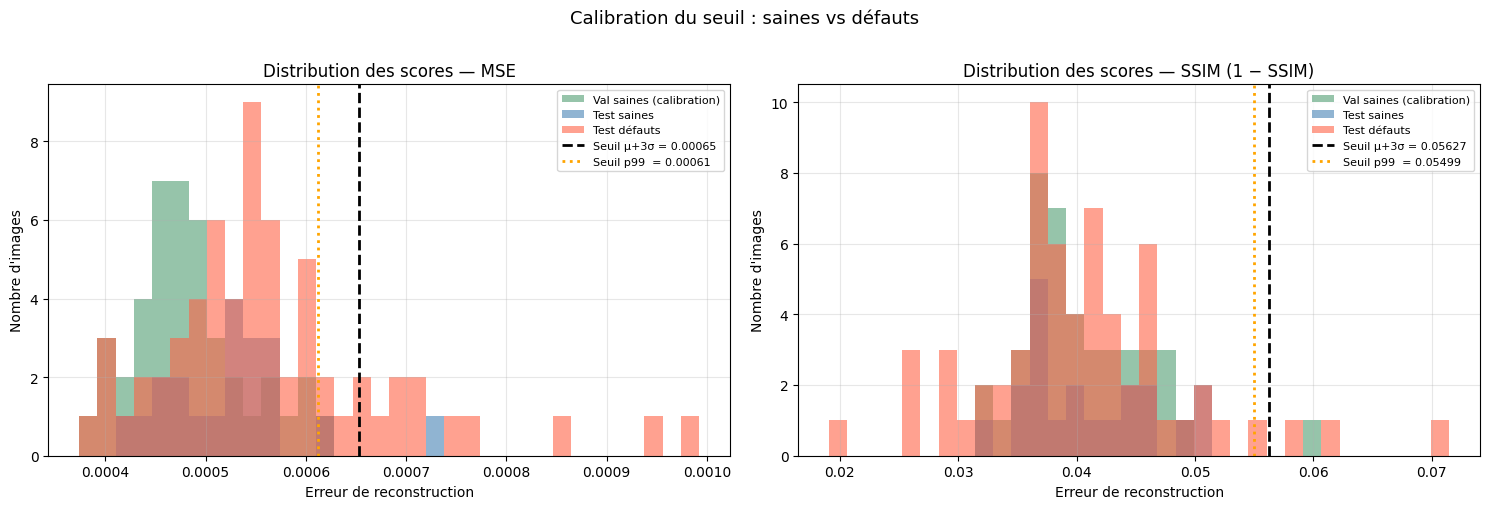

In [14]:
# ── Histogrammes : saines vs défauts + lignes de seuil ────
good_mask   = y_test_arr == "good"
defect_mask = ~good_mask

configs = [
    (test_err_mse,  val_err_mse,  thresh_mse_kstd,  thresh_mse_p99,  "MSE"),
    (test_err_ssim, val_err_ssim, thresh_ssim_kstd, thresh_ssim_p99, "SSIM (1 − SSIM)"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (test_err, val_err, t_kstd, t_p99, title) in zip(axes, configs):
    bins = np.linspace(
        min(test_err.min(), val_err.min()),
        max(test_err.max(), val_err.max()),
        35
    )
    ax.hist(val_err,               bins=bins, alpha=0.5, color="seagreen",  label="Val saines (calibration)")
    ax.hist(test_err[good_mask],   bins=bins, alpha=0.6, color="steelblue", label="Test saines")
    ax.hist(test_err[defect_mask], bins=bins, alpha=0.6, color="tomato",    label="Test défauts")
    ax.axvline(t_kstd, color="black",  linestyle="--", linewidth=2,
               label=f"Seuil μ+3σ = {t_kstd:.5f}")
    ax.axvline(t_p99,  color="orange", linestyle=":",  linewidth=2,
               label=f"Seuil p99  = {t_p99:.5f}")
    ax.set_title(f"Distribution des scores — {title}", fontsize=12)
    ax.set_xlabel("Erreur de reconstruction")
    ax.set_ylabel("Nombre d'images")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Calibration du seuil : saines vs défauts", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. Carte d'erreur par pixel (heatmap) et évaluation AUROC

Pour chaque image on calcule l'erreur quadratique **par pixel** (moyenne sur les 3 canaux RGB) afin de localiser visuellement les zones anormales.

L'évaluation quantitative repose sur l'**AUROC** (Area Under the ROC Curve) :

| Niveau | Score | Label |
|---|---|---|
| **Image** | erreur scalaire par image | 0 = saine, 1 = défaut |
| **Pixel** | heatmap aplatie | masque ground-truth GT (MVTec) |

Un AUROC pixel > 0.90 est considéré comme bon sur MVTec AD.

In [15]:
def load_masks(data_dir: str, img_size=(128, 128)) -> np.ndarray:
    """Charge les masques GT MVTec. Retourne des zéros pour les images 'good'."""
    masks = []
    test_dir = os.path.join(data_dir, "test")
    gt_dir   = os.path.join(data_dir, "ground_truth")

    for label in sorted(os.listdir(test_dir)):
        label_dir = os.path.join(test_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for fname in sorted(os.listdir(label_dir)):
            if not fname.lower().endswith((".png", ".jpg", ".bmp")):
                continue
            if label == "good":
                masks.append(np.zeros(img_size, dtype=np.float32))
            else:
                stem      = os.path.splitext(fname)[0]
                mask_path = os.path.join(gt_dir, label, f"{stem}_mask.png")
                if os.path.exists(mask_path):
                    m = Image.open(mask_path).convert("L").resize(img_size, Image.NEAREST)
                    masks.append((np.array(m) > 0).astype(np.float32))
                else:
                    masks.append(np.zeros(img_size, dtype=np.float32))

    return np.stack(masks)

masks_test = load_masks(DATA_DIR)
n_with_mask = (masks_test.sum(axis=(1, 2)) > 0).sum()
print(f"Masques chargés : {masks_test.shape}  |  images avec masque non-nul : {n_with_mask}")

Masques chargés : (83, 128, 128)  |  images avec masque non-nul : 63


C:\Users\valeuxm\AppData\Local\Temp\ipykernel_38668\178758739.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


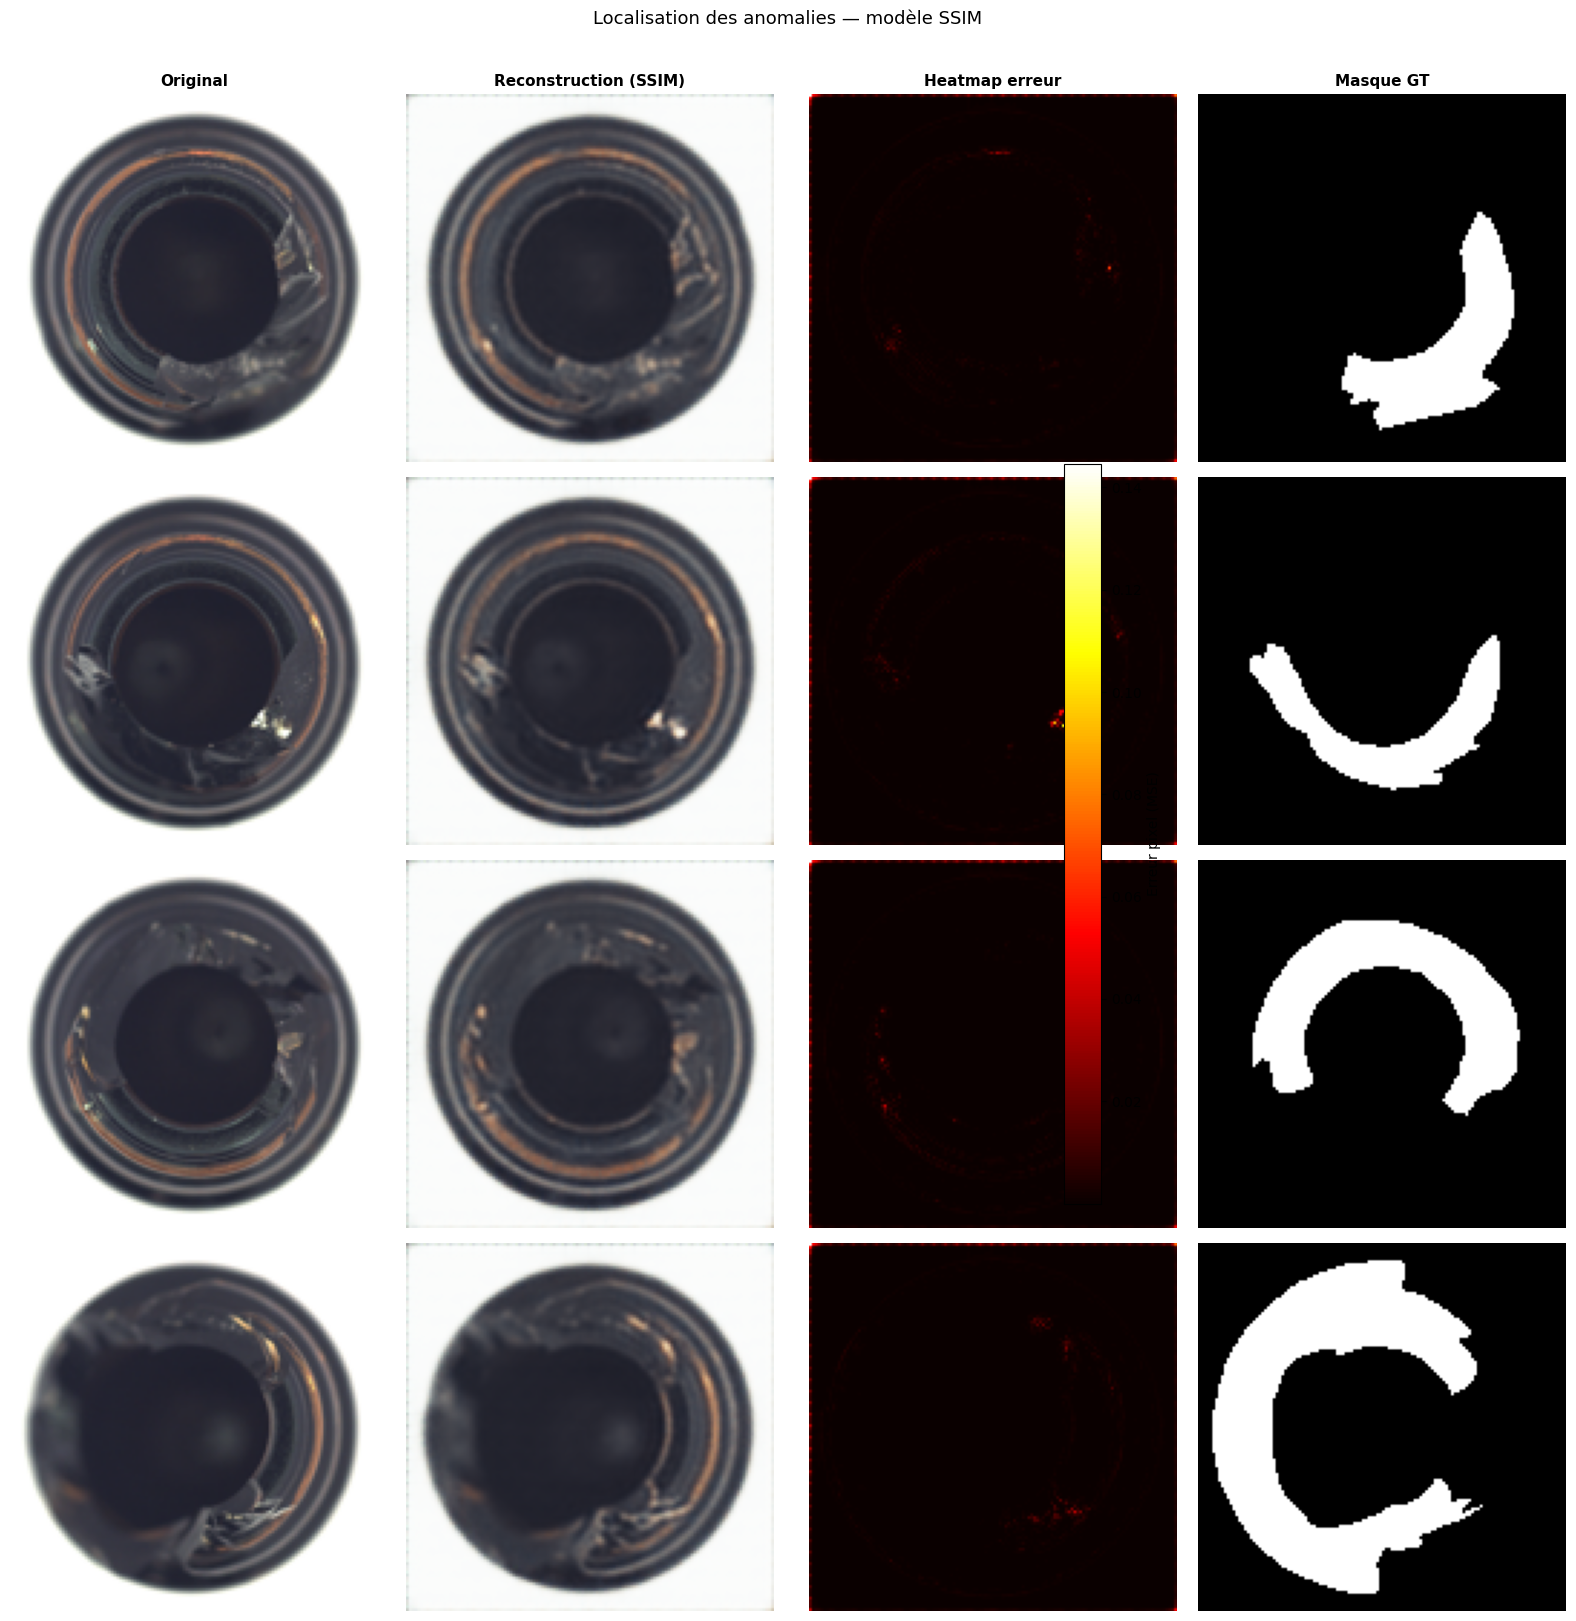

In [16]:
def compute_heatmaps(model, images):
    """Erreur quadratique par pixel, moyennée sur les 3 canaux → (N, H, W)."""
    preds = model.predict(images, batch_size=32, verbose=0)
    return preds, np.mean((preds - images) ** 2, axis=-1)

preds_mse,  heatmaps_mse  = compute_heatmaps(autoencoder_mse,  X_test)
preds_ssim, heatmaps_ssim = compute_heatmaps(autoencoder_ssim, X_test)

# ── Visualisation : 4 images défectueuses ─────────────────
defect_idx = np.where(defect_mask)[0][:4]

fig, axes = plt.subplots(len(defect_idx), 4, figsize=(16, 4 * len(defect_idx)))
titles = ["Original", "Reconstruction (SSIM)", "Heatmap erreur", "Masque GT"]
for col, t in enumerate(titles):
    axes[0, col].set_title(t, fontsize=11, fontweight="bold")

for row, idx in enumerate(defect_idx):
    axes[row, 0].imshow(X_test[idx])
    axes[row, 1].imshow(np.clip(preds_ssim[idx], 0, 1))
    im = axes[row, 2].imshow(heatmaps_ssim[idx], cmap="hot")
    axes[row, 3].imshow(masks_test[idx], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(y_test_arr[idx], fontsize=9)
    for col in range(4):
        axes[row, col].axis("off")

plt.colorbar(im, ax=axes[:, 2].tolist(), shrink=0.6, label="Erreur pixel (MSE)")
plt.suptitle("Localisation des anomalies — modèle SSIM", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

=== AUROC niveau image ===
  MSE  : 0.6056
  SSIM : 0.4595

=== AUROC niveau pixel (63 images avec masque) ===
  MSE  : 0.7147
  SSIM : 0.4567


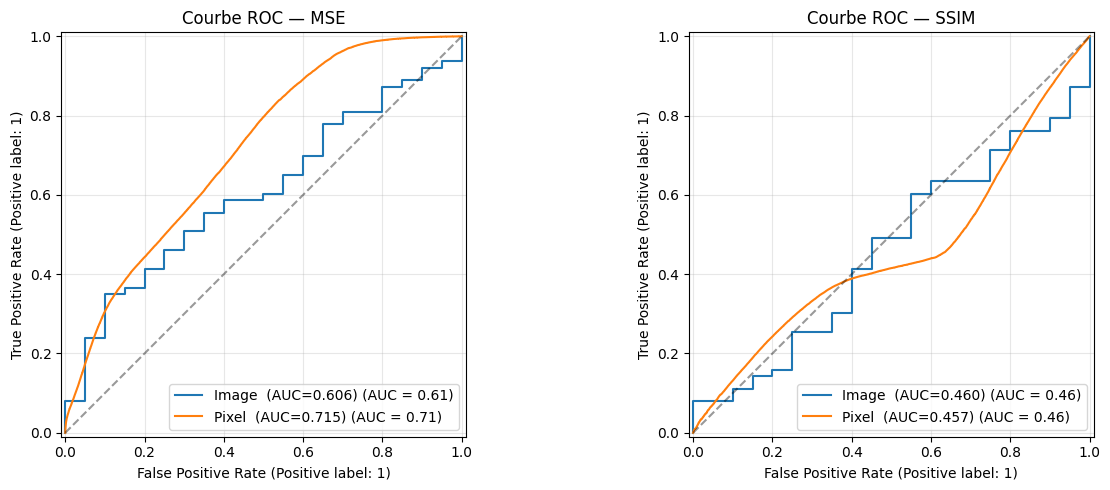

In [17]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── AUROC niveau image ────────────────────────────────────
y_img = (y_test_arr != "good").astype(int)

auroc_img_mse  = roc_auc_score(y_img, test_err_mse)
auroc_img_ssim = roc_auc_score(y_img, test_err_ssim)

print("=== AUROC niveau image ===")
print(f"  MSE  : {auroc_img_mse:.4f}")
print(f"  SSIM : {auroc_img_ssim:.4f}")

# ── AUROC niveau pixel (images défectueuses avec masque GT) ─
has_mask = masks_test.sum(axis=(1, 2)) > 0
if has_mask.sum() > 0:
    flat_gt        = masks_test[has_mask].flatten()
    auroc_pix_mse  = roc_auc_score(flat_gt, heatmaps_mse[has_mask].flatten())
    auroc_pix_ssim = roc_auc_score(flat_gt, heatmaps_ssim[has_mask].flatten())
    print(f"\n=== AUROC niveau pixel ({has_mask.sum()} images avec masque) ===")
    print(f"  MSE  : {auroc_pix_mse:.4f}")
    print(f"  SSIM : {auroc_pix_ssim:.4f}")
else:
    print("\nAucun masque GT trouvé — AUROC pixel non calculable.")
    auroc_pix_mse = auroc_pix_ssim = None

# ── Courbes ROC ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, err_img, hmap, name in zip(
    axes,
    [test_err_mse,  test_err_ssim],
    [heatmaps_mse,  heatmaps_ssim],
    ["MSE",         "SSIM"]
):
    RocCurveDisplay.from_predictions(
        y_img, err_img, ax=ax,
        name=f"Image  (AUC={roc_auc_score(y_img, err_img):.3f})"
    )
    if has_mask.sum() > 0:
        RocCurveDisplay.from_predictions(
            masks_test[has_mask].flatten(), hmap[has_mask].flatten(), ax=ax,
            name=f"Pixel  (AUC={roc_auc_score(masks_test[has_mask].flatten(), hmap[has_mask].flatten()):.3f})"
        )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"Courbe ROC — {name}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interprétation des résultats AUROC

| Niveau | MSE | SSIM | Référence MVTec |
|---|---|---|---|
| **Image** | `auroc_img_mse` | `auroc_img_ssim` | > 0.85 acceptable |
| **Pixel** | `auroc_pix_mse` | `auroc_pix_ssim` | > 0.90 bon |

**Points de lecture :**
- Un AUROC image élevé confirme que l'auto-encodeur distingue bien les saines des défectueuses au niveau global.
- Un AUROC pixel élevé valide la **localisation** des anomalies : la heatmap d'erreur se superpose aux zones réellement défectueuses.
- L'écart SSIM − MSE au niveau pixel indique l'apport de la perte structurelle pour la localisation fine des défauts de texture.
- Si l'AUROC pixel est < 0.80, envisager un **lissage gaussien** de la heatmap (`scipy.ndimage.gaussian_filter`) avant le seuillage, ou passer à une architecture U-Net.